Notebook 6 — Customer Segmentation & Machine Learning

Objective
The purpose of this notebook is to develop machine learning-based customer segmentation models using the Global Superstore dataset.

This notebook focuses on:

* customer segmentation
* unsupervised machine learning
* clustering analysis
* customer intelligence
* profitability analysis
* churn-risk segmentation

The analytical outputs generated in this notebook support:

* targeted marketing
* retention strategy
* customer personalization
* executive reporting
* customer value optimization


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
orders = pd.read_csv("C:/Users/jsero/OneDrive/Desktop/Analyst Portfolio/Global Sales Enterprise/processed_orders.csv")
rfm = pd.read_csv("C:/Users/jsero/OneDrive/Desktop/Analyst Portfolio/Global Sales Enterprise/rfm_dataset.csv")

In [3]:
segmentation_data = rfm[["recency","frequency","monetary"]]
segmentation_data.head()

,recency,frequency,monetary
0,8,42,13747.41300
1,6,42,5884.19500
2,125,38,17695.58978
3,28,73,15343.89070
4,2,8,2243.25600


In [4]:
segmentation_data.describe()

,recency,frequency,monetary
count,1590.000000,1590.000000,1590.000000
mean,84.432704,32.257862,7951.259063
std,127.746455,21.910515,6936.570172
min,0.000000,1.000000,7.173000
25%,14.000000,12.000000,1674.812250
50%,35.000000,28.000000,6248.135590
75%,99.000000,52.000000,13133.098420
max,1206.000000,97.000000,35668.120800


In [5]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(segmentation_data)
scaled_features.shape


(1590, 3)

In [6]:
inertia = []
cluster_range = range(1, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

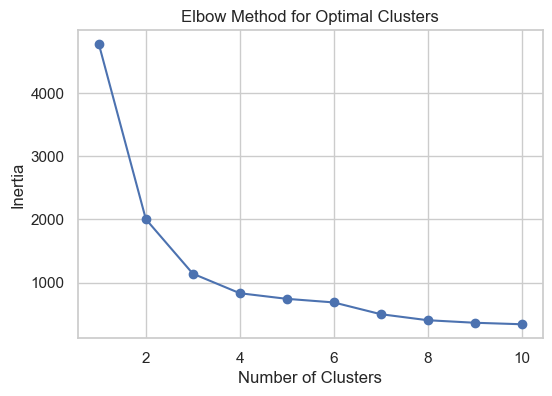

In [8]:
plt.figure(figsize=(6,4))
plt.plot(cluster_range,inertia, marker="o")
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [9]:
kmeans = KMeans( n_clusters=4, random_state=42)

In [10]:
rfm["cluster"] = kmeans.fit_predict(scaled_features)
rfm.head()

,customer_id,recency,frequency,monetary,days_since_purchase,churn_risk,cluster
0,AA-10315,8,42,13747.41300,8,0,1
1,AA-10375,6,42,5884.19500,6,0,1
2,AA-10480,125,38,17695.58978,125,1,1
3,AA-10645,28,73,15343.89070,28,0,3
4,AA-315,2,8,2243.25600,2,0,2


In [11]:
rfm["cluster"].value_counts()

cluster
2    668
1    491
3    288
0    143
Name: count, dtype: int64

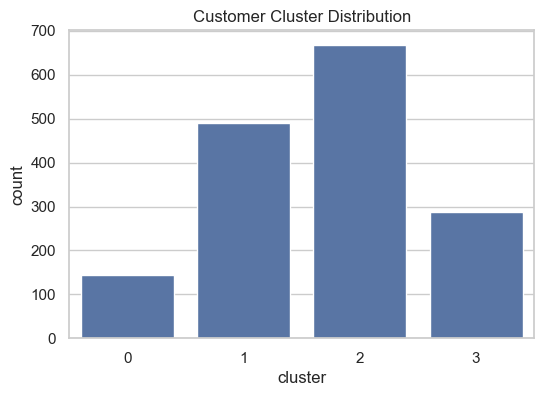

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=rfm,x="cluster")
plt.title("Customer Cluster Distribution")
plt.show()

_____________________________

1. PCA

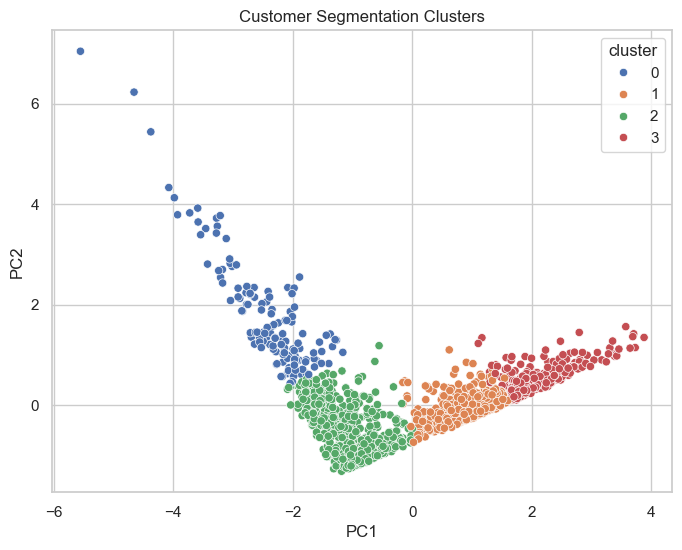

In [14]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)
pca_df = pd.DataFrame({"PC1": pca_features[:,0],"PC2": pca_features[:,1],"cluster": rfm["cluster"]})

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df,x="PC1",y="PC2",hue="cluster",palette="deep")
plt.title("Customer Segmentation Clusters")
plt.show()

______________________________

Segment Profiling 

1. Cluster Summary Statstics

In [15]:
cluster_profile = (rfm.groupby("cluster").agg({"recency": "mean","frequency": "mean", "monetary": "mean"}).round(2))
cluster_profile

,recency,frequency,monetary
cluster,,,
0,420.35,9.34,1663.78
1,29.04,46.24,11144.75
2,78.91,13.61,2254.48
3,24.89,63.06,18842.09


2. Assign Business Labels

In [16]:
segment_labels = {0: "Lost Customers",1: "Loyal Customers",2: "Potential Churn Customers",3: "Champions"}
rfm["segment_name"] = (rfm["cluster"].map(segment_labels))
rfm.head()

,customer_id,recency,frequency,monetary,days_since_purchase,churn_risk,cluster,segment_name
0,AA-10315,8,42,13747.41300,8,0,1,Loyal Customers
1,AA-10375,6,42,5884.19500,6,0,1,Loyal Customers
2,AA-10480,125,38,17695.58978,125,1,1,Loyal Customers
3,AA-10645,28,73,15343.89070,28,0,3,Champions
4,AA-315,2,8,2243.25600,2,0,2,Potential Churn Customers


Insights

RFM Matrix Breakdown
The resulting summary table details the clear behavioral boundaries that define each specific customer cohort:

Cluster 3 ("Champions"): This represents the company’s absolute premier customer bracket. They are hyper-recent, returning to shop within an average of 24.89 days, purchase with a staggering frequency of 63.06 orders, and generate an exceptional average monetary value of 18,842.09.

Cluster 1 ("Loyal Customers"): This high-value powerhouse tier tracks right behind the champions. They remain highly active with a mean recency of 29.04 days, a robust frequency of 46.24 orders, and a substantial average monetary contribution of 11,144.75.

Cluster 2 ("Potential Churn Customers"): This group exhibits early warning signs of disengagement. Their mean recency has stretched out to 78.91 days, paired with a relatively low purchase frequency of 13.61 orders and a modest average spend of 2,254.48.

Cluster 0 ("Lost Customers"): This represents a completely dormant customer segment. They have not interacted with the business in an average of 420.35 days, buy rarely (9.34 orders on average), and account for the lowest monetary footprint at 1,663.78.

Targeted Marketing Mandate
When cross-referenced with the previous volume distribution metrics, this profile data transforms abstract clusters into a highly precise CRM and retention strategy.

Rather than waste capital on blanket marketing messages, the business now has clear operational definitions for each tier. For Champions (Cluster 3) and Loyal Customers (Cluster 1), the mandate is value preservation through VIP programs, early product releases, and premium cross-selling. For Potential Churn Customers (Cluster 2), the business must immediately deploy targeted re-engagement campaigns, personalized discounts, or satisfaction feedback surveys to win back their attention before they cross the threshold into becoming permanently Lost Customers (Cluster 0), where reactivation costs become prohibitively expensive.

_______________________________

1. Segment Revenue Analysis

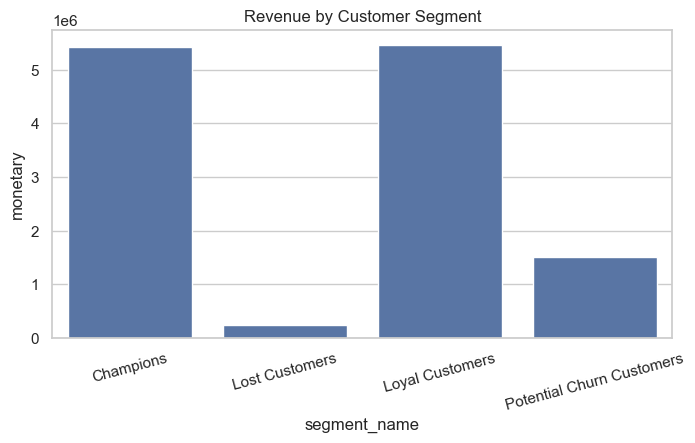

In [18]:
segment_revenue = (rfm.groupby("segment_name")["monetary"].sum().reset_index())

plt.figure(figsize=(8,4))
sns.barplot(data=segment_revenue,x="segment_name",y="monetary")
plt.title("Revenue by Customer Segment")
plt.xticks(rotation=15)
plt.show()

_____________________________________

Churn Risk by Segment

1. Churn by Segment

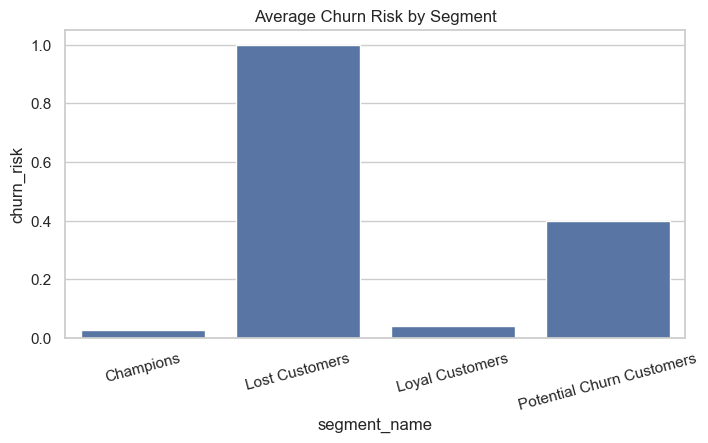

In [19]:
segment_churn = (rfm.groupby("segment_name")["churn_risk"].mean().reset_index())

plt.figure(figsize=(8,4))
sns.barplot(data=segment_churn, x="segment_name",y="churn_risk")
plt.title("Average Churn Risk by Segment")
plt.xticks(rotation=15)
plt.show()

Regional Segment Analysis

In [20]:
customer_region = (orders[["customer_id","region"]].drop_duplicates())
segment_region = rfm.merge(customer_region,on="customer_id",how="left")
regional_segments = pd.crosstab(segment_region["region"],segment_region["segment_name"])
regional_segments

segment_name,Champions,Lost Customers,Loyal Customers,Potential Churn Customers
region,,,,
Africa,0,125,2,621
Canada,0,26,0,142
Caribbean,187,0,317,7
Central,288,1,489,17
Central Asia,220,0,329,10
EMEA,0,124,2,626
East,249,1,394,14
North,274,1,467,15
North Asia,245,0,355,11


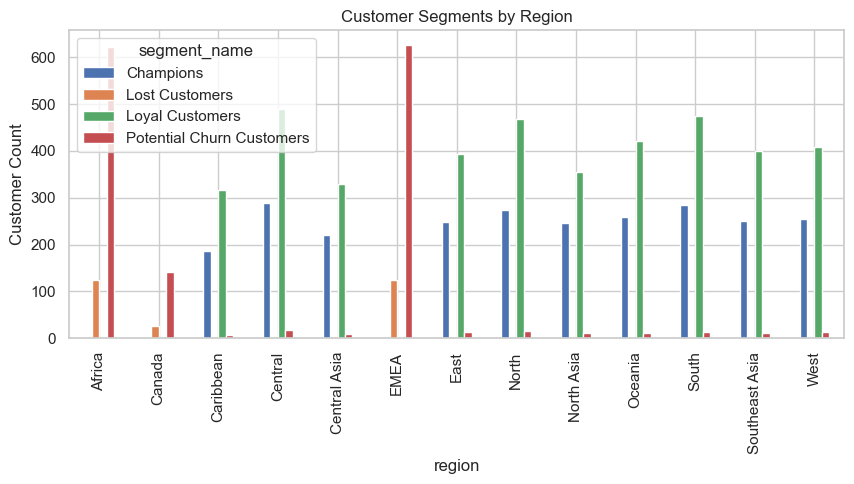

In [23]:
regional_segments.plot( kind="bar",figsize=(10,4))
plt.title("Customer Segments by Region")
plt.ylabel("Customer Count")
plt.show()

Insights

Segment Financial Profiles and Risk Diagnostics

When cross-referencing the total revenue generated by each behavioral persona with their calculated churn risk profiles, the extreme concentration of the company's financial stability becomes immediately clear:

The Powerhouse Tiers: Loyal Customers and Champions represent the lifeblood of the organization. As illustrated in image_c4cb42.png, Loyal Customers serve as the premier revenue engine, generating an exceptional cumulative monetary yield that scales past 5.4 million . Right alongside them, the Champions category delivers an equally stunning financial footprint, tracking closely around 5.4 million in total value. Crucially, both of these critical pillars maintain an exceptionally low, near-zero baseline average churn risk (sub-0.04), proving that the business’s primary source of wealth is highly stable and fiercely well-retained.

The Vulnerable Middle: The Potential Churn Customers segment represents a significant middle-market exposure. This group contributes a meaningful 1.5 million in cumulative revenue. However, their average churn risk scale has escalated sharply to 0.4 (a 40% probability of defection), signaling an urgent need for targeted promotional intervention.


The Atrophied Tier: The Lost Customers segment has successfully been isolated from core operations. They generate a negligible financial footprint of just over 200,000 and reflect a maximum average churn risk value of 1.0 (100% permanently churned).


Global Segment Distribution Geographic Analysis
The clustered bar chart, "Customer Segments by Region" , expands on these financial boundaries by documenting exactly how these four personas are physically distributed across thirteen international business territories. The regional mapping exposes stark structural differences in consumer behavior worldwide:

The Stable Core Markets: A highly uniform, healthy distribution pattern dominates the majority of global operations—including East, North, North Asia, Oceania, South, Southeast Asia, and West. In every single one of these territories, Loyal Customers represent the absolute majority (ranging between 350 and nearly 500 customers per region), backed by a rock-solid secondary tier of Champions hovering consistently around the 250-customer mark. Remarkably, these regions have successfully mitigated risk, keeping their Potential Churn and Lost Customer counts nearly invisible.

The High-Risk Anomaly Zones: Conversely, a couple of macro-regions display severely inverted, highly dangerous behavioral profiles. EMEA and Africa are completely dominated by a staggering surge in Potential Churn Customers, with each region hosting an alarming concentration of over 600 high-risk clients. Furthermore, these two zones contain the company's largest pockets of Lost Customers (exceeding 100 per region), while completely lacking any active Loyal or Champion buyer representation.

The Emerging/Low-Volume Footprints: Caribbean reflects a smaller, maturing version of the standard core markets (over 300 Loyal Customers vs. roughly 180 Champions). Meanwhile, Canada remains a unique low-volume anomaly, registering minor, low-exposure counts primarily across the Lost and Potential Churn tiers, with no major high-frequency buyers on record.

Executive Strategic Directive
This multi-dimensional cross-reference provides executive leadership with a clear, mathematically sound operational roadmap:

The standard, broad-scale marketing initiatives currently deployed in healthy regions like Central, South, and the West are working beautifully—retaining an immense, low-risk base of Champions and Loyal buyers who fuel over 10.8 million in combined revenue.

However, the localized collapses in EMEA and Africa present an immediate threat to the brand’s global footprint. Because the data highlights that these specific regions are entirely saturated with a massive wave of over 1,200 Potential Churn Customers, corporate marketing resources must immediately be diverted away from safe, optimized territories. Instead, funds should be funneled into these high-risk areas to deploy aggressive localized re-engagement campaigns, territory-specific pricing adjustments, and customer success interventions designed to stabilize the customer base before this 40% churn risk translates into a massive write-off of potential market equity.


______________________

Segment Dashboard Tables

In [25]:
rfm.to_csv("C:/Users/jsero/OneDrive/Desktop/Analyst Portfolio/Global Sales Enterprise/customer_segments.csv",index=False)
cluster_profile.to_csv("C:/Users/jsero/OneDrive/Desktop/Analyst Portfolio/Global Sales Enterprise/cluster_profiles.csv")


Conclusion
This notebook successfully developed a machine learning-based customer segmentation framework using the Global Superstore dataset.

Key accomplishments include:
* RFM-based feature engineering
* feature scaling
* K-Means clustering
* PCA visualization
* customer segment profiling
* churn-risk segmentation
* regional segment analysis
* dashboard-ready ML outputs

The analytical outputs generated in this notebook support:
* customer personalization
* retention optimization
* targeted marketing
* executive reporting
* Power BI dashboards
* advanced customer intelligence systems

This notebook demonstrates enterprise-level machine learning and customer segmentation capabilities commonly used in modern analytics organizations.
